# Neural PDE Laboratory · 02
## Poisson surfaces and limits of continuous losses

Experiments **4–5** of the laboratory. This notebook is self-contained:
run it in a fresh kernel; no earlier notebook or saved result is required.

[All seven notebooks](Neural_PDE_Laboratory.ipynb) · [Setup and guide](NOTEBOOK_README.md)

Install `experiments/requirements-notebook.txt`, then select **Restart Kernel and
Run All Cells**. The supplied static plots and diagnostics can be read on GitHub.
Interactive explorers are separate, self-contained HTML files in `notebook_outputs/`;
download that folder and open `index.html` in a browser, or regenerate them locally.

Python 3.11+; CPU / float64. Set `RUN_MODE = "thorough"` for longer training runs.

**Notation:** $u$ is the reference state, $u_\theta$ the neural state,
$r_\theta=\mathcal L u_\theta-f$, $\mathcal J$ a continuous residual loss,
$\widehat{\mathcal J}$ its numerical approximation, and $\mathcal E$ an energy.
A hat indicates sampling or quadrature. We check solution error separately from training loss.

In [1]:
# Uncomment only if these packages are missing, then restart the kernel.
# %pip install "numpy>=2.0" scipy matplotlib "torch>=2.2" "plotly>=5.24,<7" ipython

In [2]:
from pathlib import Path
import copy, io, json, math, platform, time
import numpy as np
import scipy
from scipy.linalg import solve_banded
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import torch
from torch import nn
import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Markdown, Image

RUN_MODE = "quick"               # "quick" or "thorough"
SEED = 7
OUTPUT_DIR = Path.cwd() / "notebook_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
NOTEBOOK_START = time.perf_counter()
metrics = []
FIGURE_NAMES, INTERACTIVE_NAMES = [], []
assert RUN_MODE in {"quick", "thorough"}
torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
torch.manual_seed(SEED)
np.random.seed(SEED)
BUDGET = {"adam_1d": 900, "lbfgs_1d": 180, "adam_2d": 1100,
          "lbfgs_2d": 260, "boundary_adam": 900}
if RUN_MODE == "thorough":
    BUDGET = {key: 2 * value for key, value in BUDGET.items()}
versions = {"python": platform.python_version(), "numpy": np.__version__,
            "scipy": scipy.__version__, "matplotlib": matplotlib.__version__,
            "torch": torch.__version__, "plotly": plotly.__version__}
print(json.dumps(versions, indent=2))
print(f"CPU / float64 / seed {SEED} / {RUN_MODE} mode")

{
  "python": "3.13.9",
  "numpy": "2.4.2",
  "scipy": "1.17.0",
  "matplotlib": "3.10.8",
  "torch": "2.10.0",
  "plotly": "6.9.0"
}
CPU / float64 / seed 7 / quick mode


## Reading and saving the plots

Static figures are saved as PNG and PDF and embedded in this notebook. Interactive
plots are saved as offline HTML files: open their links locally to rotate, zoom,
and animate them. GitHub displays the static figures without executing JavaScript.

In [3]:
palette = {"navy": "#10243A", "teal": "#00A6A6", "orange": "#F28C45",
           "pink": "#DC4778", "blue": "#4878D0", "ink": "#183449", "muted": "#63788A"}
plt.rcParams.update({
    "figure.facecolor": "#F7FAFC", "axes.facecolor": "#F7FAFC",
    "axes.edgecolor": "#CAD6DF", "axes.labelcolor": palette["ink"],
    "text.color": palette["ink"], "xtick.color": palette["muted"],
    "ytick.color": palette["muted"], "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#DCE5EB", "grid.alpha": 0.65,
    "lines.linewidth": 2.3, "figure.dpi": 110, "savefig.dpi": 170,
    "legend.frameon": False, "font.family": "DejaVu Sans",
    "axes.prop_cycle": matplotlib.cycler(color=[palette[k] for k in
                                  ["teal", "orange", "pink", "blue", "navy"]]),
})
sea_cmap = LinearSegmentedColormap.from_list("sea", ["#10243A", "#146F88", "#00BBB0", "#F9D879"])
wave_scale = [[0, "#153F7C"], [.25, "#21A9B5"], [.5, "#F7FAFC"],
              [.75, "#FFB16E"], [1, "#C93663"]]

def style_3d(ax, title=None):
    if title:
        ax.set_title(title)
    ax.view_init(elev=28, azim=-128)
    ax.set_box_aspect((1, 1, .65))
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis._axinfo["grid"]["color"] = (0.78, 0.84, 0.88, 0.35)
    ax.tick_params(labelsize=8, pad=1)

def save_figure(fig, name):
    if name not in FIGURE_NAMES:
        FIGURE_NAMES.append(name)
    fig.savefig(OUTPUT_DIR / f"{name}.png", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{name}.pdf", bbox_inches="tight")
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=130, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

def show_interactive(fig, name):
    if name not in INTERACTIVE_NAMES:
        INTERACTIVE_NAMES.append(name)
    fig.update_layout(template="plotly_dark", paper_bgcolor="#10243A",
                      plot_bgcolor="#10243A", font=dict(family="Arial", size=13),
                      margin=dict(l=40, r=55, t=130, b=75), height=680)
    fig.update_layout(title=dict(x=.035, y=.97, xanchor="left", font=dict(size=19)))
    for menu in fig.layout.updatemenus:
        menu.update(y=1.04, yanchor="bottom", x=0, xanchor="left",
                    bgcolor="#E5EFF5", bordercolor="#9FB8CA",
                    font=dict(color="#10243A", size=12))
    fig.update_scenes(bgcolor="#10243A",
        xaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"),
        yaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"),
        zaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"))
    config = {"displaylogo": False, "responsive": True}
    fig.write_html(OUTPUT_DIR / f"{name}.html", include_plotlyjs=True,
                   full_html=True, config=config, auto_play=False)
    # Keep notebook previews small: JavaScript and animation data live in HTML.
    relative = (OUTPUT_DIR / f"{name}.html").relative_to(Path.cwd()).as_posix()
    display(Markdown(f"[Open interactive explorer]({relative}) — "
                     "open locally in a browser; GitHub previews show the static plots."))

def grad_scalar(u, x):
    return torch.autograd.grad(u.sum(), x, create_graph=True)[0]

def mlp(input_dim, width=32, depth=2):
    layers = [nn.Linear(input_dim, width), nn.Tanh()]
    for _ in range(depth - 1):
        layers.extend([nn.Linear(width, width), nn.Tanh()])
    return nn.Sequential(*layers, nn.Linear(width, 1))

def train_model(model, objective, adam_steps, lbfgs_steps=0, diagnostic=None):
    """Log each objective evaluation, including repeated L-BFGS closure calls."""
    start = time.perf_counter()
    history = {"evaluation": [], "loss": [], "error_eval": [], "error": []}
    evaluations = 0
    opt = torch.optim.Adam(model.parameters(), lr=2e-3)
    def evaluate():
        nonlocal evaluations
        value = objective()
        evaluations += 1
        history["evaluation"].append(evaluations)
        history["loss"].append(value.detach().item())
        return value
    for step in range(adam_steps):
        opt.zero_grad(set_to_none=True)
        loss = evaluate()
        loss.backward()
        opt.step()
        if diagnostic is not None and (step == 0 or (step + 1) % 100 == 0):
            history["error_eval"].append(evaluations)
            history["error"].append(diagnostic())
    if lbfgs_steps:
        opt = torch.optim.LBFGS(model.parameters(), max_iter=lbfgs_steps,
                 max_eval=2*lbfgs_steps, history_size=40, line_search_fn="strong_wolfe",
                 tolerance_grad=1e-10, tolerance_change=1e-13)
        def closure():
            opt.zero_grad(set_to_none=True)
            value = evaluate()
            value.backward()
            return value
        opt.step(closure)
    if diagnostic is not None:
        history["error_eval"].append(evaluations)
        history["error"].append(diagnostic())
    history["seconds"] = time.perf_counter() - start
    return history

## 4 · A neural Poisson surface on the square

Solve
$$-\Delta u=2\pi^2\sin(\pi x)\sin(\pi y),\quad (x,y)\in(0,1)^2,
\qquad u|_{\partial\Omega}=0.$$
Use $u_\theta=x(1-x)y(1-y)N_\theta(x,y)$ to enforce all four edges exactly.
Scrambled Sobol points approximate a uniform-domain residual integral. An independent
regular grid reveals both state error and residual structure. The residual is scaled by $2\pi^2$.

In [4]:
class Poisson2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = mlp(2, width=32, depth=3)
    def forward(self, xy):
        x, y = xy[:, :1], xy[:, 1:2]
        return x*(1-x)*y*(1-y)*self.net(2*xy-1)

def p2_residual(model, xy):
    xy = xy.detach().requires_grad_()
    u = model(xy)
    du = grad_scalar(u, xy)
    uxx = grad_scalar(du[:, :1], xy)[:, :1]
    uyy = grad_scalar(du[:, 1:2], xy)[:, 1:2]
    f = 2*np.pi**2*torch.sin(np.pi*xy[:, :1])*torch.sin(np.pi*xy[:, 1:2])
    return (-uxx-uyy-f)/(2*np.pi**2)

torch.manual_seed(SEED)
p2_model = Poisson2D()
p2_train = torch.quasirandom.SobolEngine(2, scramble=True, seed=SEED).draw(768).double()
p2_history = train_model(p2_model, lambda: p2_residual(p2_model, p2_train).square().mean(),
                         BUDGET["adam_2d"], BUDGET["lbfgs_2d"])
p2_axis = np.linspace(0, 1, 81)
p2_X, p2_Y = np.meshgrid(p2_axis, p2_axis)
p2_xy = torch.tensor(np.c_[p2_X.ravel(), p2_Y.ravel()])
with torch.no_grad():
    p2_pred = p2_model(p2_xy).numpy().reshape(p2_X.shape)
p2_exact = np.sin(np.pi*p2_X)*np.sin(np.pi*p2_Y)
p2_error = p2_pred-p2_exact
p2_r = p2_residual(p2_model, p2_xy).detach().numpy().reshape(p2_X.shape)
p2_integrate = lambda z: np.trapezoid(np.trapezoid(z, p2_axis, axis=1), p2_axis)
p2_rel = float(np.sqrt(p2_integrate(p2_error**2)/p2_integrate(p2_exact**2)))
p2_bc = np.r_[p2_pred[0], p2_pred[-1], p2_pred[:,0], p2_pred[:,-1]]
assert np.max(np.abs(p2_bc)) == 0
assert np.isfinite(p2_r).all()
metrics.append(dict(experiment="Square Poisson PINN", relative_l2=p2_rel, seconds=p2_history["seconds"]))
print(f"Relative L2 error: {p2_rel:.3e}; normalized residual RMS: {np.sqrt(p2_integrate(p2_r**2)):.3e}")
print(f"Maximum boundary error: {np.max(np.abs(p2_bc)):.1e}; training: {p2_history['seconds']:.1f} s")

Relative L2 error: 9.707e-06; normalized residual RMS: 1.545e-04
Maximum boundary error: 0.0e+00; training: 10.6 s


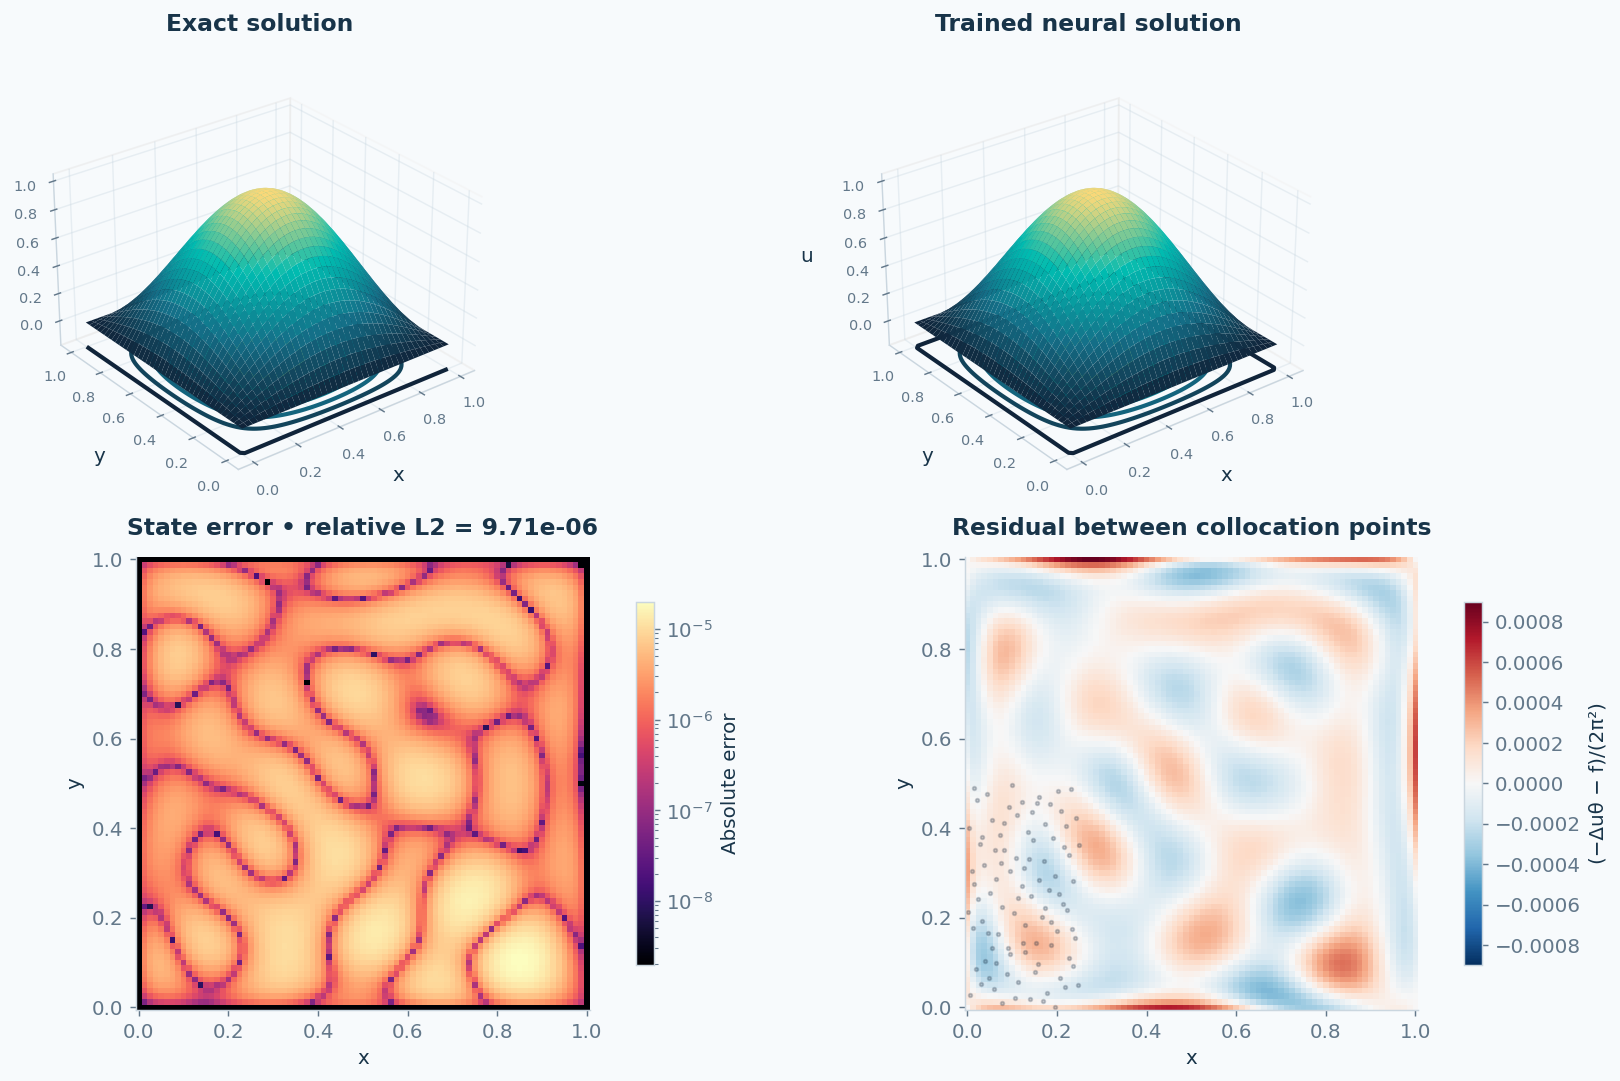

[Open interactive explorer](notebook_outputs/04_poisson_explorer.html) — open locally in a browser; GitHub previews show the static plots.

In [5]:
fig = plt.figure(figsize=(13, 8.2), layout="constrained")
for index, values, title in [(1, p2_exact, "Exact solution"), (2, p2_pred, "Trained neural solution")]:
    ax = fig.add_subplot(2, 2, index, projection="3d")
    ax.plot_surface(p2_X, p2_Y, values, cmap=sea_cmap, vmin=0, vmax=1, linewidth=0,
                    rcount=65, ccount=65, antialiased=True)
    ax.contour(p2_X, p2_Y, values, zdir="z", offset=-.18, cmap=sea_cmap, levels=8)
    style_3d(ax, title)
    ax.set(xlabel="x", ylabel="y", zlabel="u", zlim=(-.18, 1.05))
ax = fig.add_subplot(223)
im = ax.pcolormesh(p2_X, p2_Y, np.maximum(np.abs(p2_error), 1e-12), cmap="magma",
        norm=LogNorm(vmin=max(1e-9, np.max(np.abs(p2_error))*1e-4), vmax=np.max(np.abs(p2_error))), shading="auto")
fig.colorbar(im, ax=ax, label="Absolute error", shrink=.8)
ax.set(title=f"State error • relative L2 = {p2_rel:.2e}", xlabel="x", ylabel="y", aspect="equal")
ax = fig.add_subplot(224)
p2_limit = np.max(np.abs(p2_r))
im = ax.pcolormesh(p2_X, p2_Y, p2_r, cmap="RdBu_r", vmin=-p2_limit, vmax=p2_limit, shading="auto")
ax.scatter(p2_train[::8,0], p2_train[::8,1], s=4, c=palette["navy"], alpha=.22)
fig.colorbar(im, ax=ax, label="(−Δuθ − f)/(2π²)", shrink=.8)
ax.set(title="Residual between collocation points", xlabel="x", ylabel="y", aspect="equal")
save_figure(fig, "04_poisson_square")

p2_fig = go.Figure()
for values, label in [(p2_pred, "Neural state"), (p2_exact, "Exact state"), (p2_error, "Signed error")]:
    p2_fig.add_trace(go.Surface(x=p2_X, y=p2_Y, z=values, name=label,
        visible=label=="Neural state", colorscale="Viridis" if label!="Signed error" else wave_scale,
        colorbar=dict(title="u" if label!="Signed error" else "Error"),
        hovertemplate="x=%{x:.2f}<br>y=%{y:.2f}<br>value=%{z:.4g}<extra></extra>"))
p2_fig.update_layout(title="Poisson explorer · state and magnified error geometry",
    scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="Selected field",
               aspectratio=dict(x=1,y=1,z=.65), uirevision="poisson"),
    updatemenus=[dict(buttons=[dict(label=label, method="update",
        args=[dict(visible=[j==i for j in range(3)])]) for i,label in
        enumerate(["Neural state", "Exact state", "Signed error"])], x=0, y=1.1)])
show_interactive(p2_fig, "04_poisson_explorer")

**Try:** change the network width or collocation count. Keep the validation grid fixed.
The interactive error surface uses its own vertical scale: it magnifies error structure,
so always read the axis values. The tiny dots in the residual map show a subset of training points.

## 5 · Two counterexamples for continuous losses

We now construct two explicit sequences of networks and evaluate their continuous
losses. Both examples can be worked out without training or collocation.

**A. An infimum without a minimizer.** For $-u''=0$, $u(0)=0$, $u(1)=1$, consider
$v_n(x)=\tanh(x/n)/\tanh(1/n)$. Define the full continuous loss
$$\mathcal J(v)=\int_0^1|v''|^2dx+|v(0)|^2+|v(1)-1|^2.$$
The sequence satisfies both endpoints exactly, so
$\mathcal J(v_n)=\int_0^1|v_n''|^2dx\to0$.
Yet a fixed finite sum of tanh neurons (plus a constant) is bounded and analytic on
$\mathbb R$: it cannot equal $x$ on an interval. The identity theorem would make it
$x$ everywhere. Hence the infimum is zero and is not attained in that class;
the output weight $1/\tanh(1/n)$ escapes to infinity.

**B. Residual decay without state convergence.** The Neumann problem
$$-u''+\frac{u}{1+u^2}=0,\qquad u'(0)=u'(1)=0$$
has unique solution $u=0$: test with $u$ and integrate to obtain
$\int_0^1(|u'|^2+u^2/(1+u^2))dx=0$.
Here the full loss is
$$\mathcal J(v)=\int_0^1|-v''+v/(1+v^2)|^2dx+|v'(0)|^2+|v'(1)|^2.$$
The one-neuron constant $v_n=(n/\tanh1)\tanh(0x+1)=n$ has
$$\mathcal J(v_n)=\frac{n^2}{(1+n^2)^2}\to0,
\qquad\|v_n-u\|_{L^2}=n\to\infty.$$
This reaction has no **global residual-to-state stability estimate**: a small
residual can accompany a large solution error. For stable problems such as
Dirichlet Poisson, suitable residual norms do control the error.

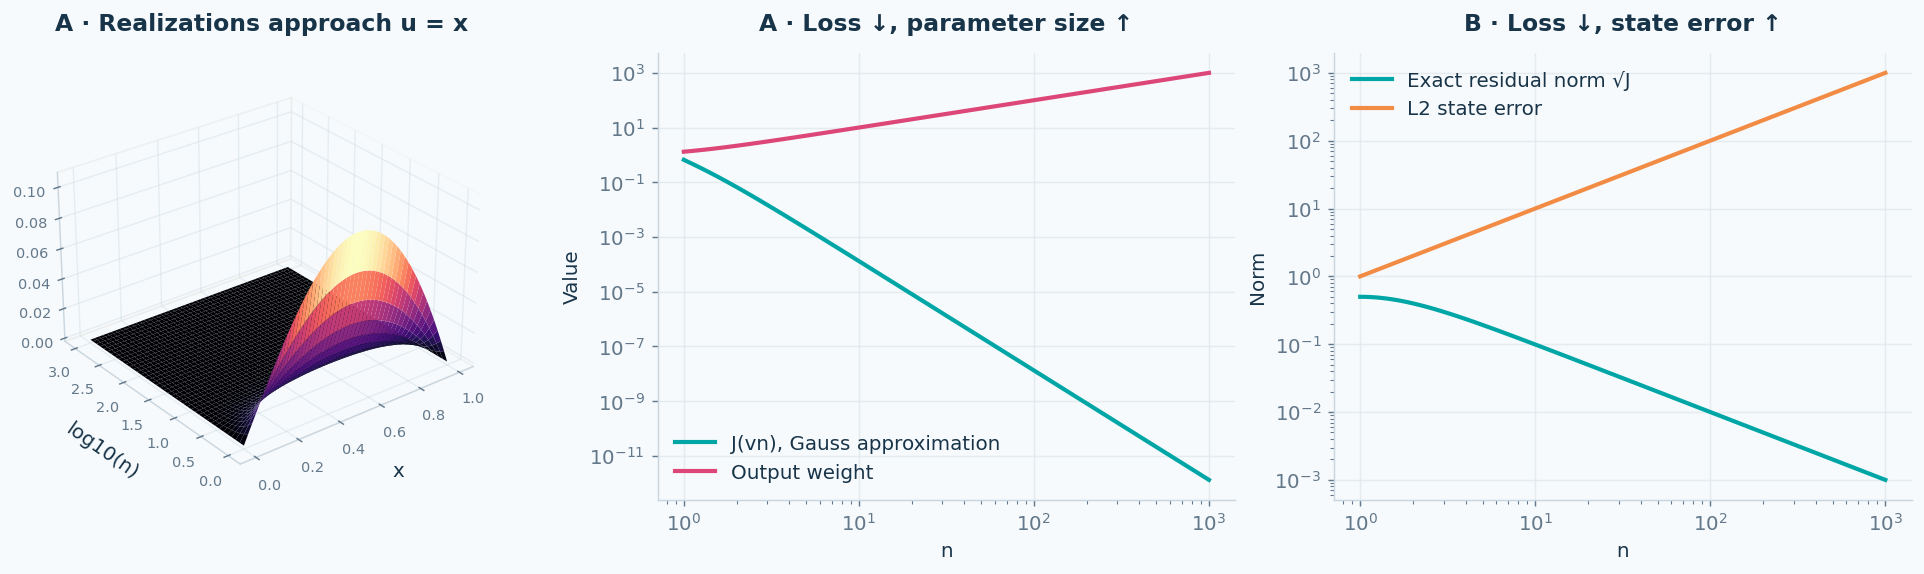

At n = 1000: example A J = 1.333e-12; example B √J = 1.000e-03, error = 1000


In [6]:
ce_n = np.logspace(0, 3, 120)
ce_x = np.linspace(0, 1, 300)
ce_v = np.tanh(ce_x[None,:]/ce_n[:,None])/np.tanh(1/ce_n[:,None])
# Quadrature evaluates example A numerically; the nonattainment statement is analytic.
ce_nodes, ce_w = np.polynomial.legendre.leggauss(180)
ce_qx = .5*(ce_nodes+1)
ce_t = np.tanh(ce_qx[None,:]/ce_n[:,None])
ce_vxx = -2*ce_t*(1-ce_t**2)/(ce_n[:,None]**2*np.tanh(1/ce_n[:,None]))
ce_J = (ce_vxx**2) @ (.5*ce_w)
ce_J_constant = ce_n**2/(1+ce_n**2)**2  # exact integral; no numerical sampling
assert np.all(np.diff(ce_J)<0) and np.all(np.diff(ce_J_constant)<0)
assert abs(ce_J[-1]*ce_n[-1]**4-4/3)<1e-4
fig = plt.figure(figsize=(15, 4.3), layout="constrained")
ax = fig.add_subplot(131, projection="3d")
ce_X, ce_N = np.meshgrid(ce_x, np.log10(ce_n))
ax.plot_surface(ce_X, ce_N, ce_v-ce_x, cmap="magma", linewidth=0)
style_3d(ax, "A · Realizations approach u = x")
ax.set(xlabel="x", ylabel="log10(n)", zlabel="vn − x")
ax = fig.add_subplot(132)
ax.loglog(ce_n, ce_J, color=palette["teal"], label="J(vn), Gauss approximation")
ax.loglog(ce_n, 1/np.tanh(1/ce_n), color=palette["pink"], label="Output weight")
ax.set(title="A · Loss ↓, parameter size ↑", xlabel="n", ylabel="Value"); ax.legend(); ax.grid()
ax = fig.add_subplot(133)
ax.loglog(ce_n, np.sqrt(ce_J_constant), color=palette["teal"], label="Exact residual norm √J")
ax.loglog(ce_n, ce_n, color=palette["orange"], label="L2 state error")
ax.set(title="B · Loss ↓, state error ↑", xlabel="n", ylabel="Norm"); ax.legend(); ax.grid()
save_figure(fig, "05_coercivity_counterexamples")
print(f"At n = {ce_n[-1]:.0f}: example A J = {ce_J[-1]:.3e}; example B √J = {np.sqrt(ce_J_constant[-1]):.3e}, error = {ce_n[-1]:.0f}")

**Try:** derive the $\mathcal J(v_n)\sim4/(3n^4)$ asymptotic in A. In B, replace the
saturating reaction by $+u$: what happens to the residual of the same constant sequence?
The two plots separate **existence in the network class** from **stability of the PDE residual**.

## Save this notebook's results

This cell records versions, settings, diagnostics and computed fields, and builds a
local gallery. Report filenames include this notebook's part number, so notebooks
can run independently in any order without overwriting each other's reports.

In [7]:
# Keep reports separate so running one notebook cannot replace another's results.
PART = '02_poisson_and_limits'
summary_metrics = list(metrics)

report = dict(part=PART, versions=versions, run_mode=RUN_MODE, seed=SEED, budgets=BUDGET,
    device="cpu", dtype=str(torch.get_default_dtype()), settings=dict(poisson_collocation=768),
    static_figures=FIGURE_NAMES, interactive_figures=INTERACTIVE_NAMES,
    metrics=summary_metrics, elapsed_seconds=time.perf_counter()-NOTEBOOK_START)
(OUTPUT_DIR / f"run_summary_{PART}.json").write_text(json.dumps(report, indent=2))
np.savez_compressed(OUTPUT_DIR / f"computed_fields_{PART}.npz", poisson_x=p2_axis, poisson_prediction=p2_pred,
        poisson_exact=p2_exact, poisson_residual=p2_r,
        counterexample_n=ce_n, counterexample_loss=ce_J,
        constant_sequence_loss=ce_J_constant)

from html import escape
cards = []
for name in FIGURE_NAMES:
    title = escape(name.replace("_", " ").title())
    cards.append(f'<figure><a href="{name}.png"><img src="{name}.png" alt="{title}"></a>'
                 f'<figcaption>{title} · <a href="{name}.pdf">PDF</a></figcaption></figure>')
links = "".join(f'<li><a href="{name}.html">{escape(name.replace("_", " ").title())}</a></li>'
                for name in INTERACTIVE_NAMES)
page = ('<!doctype html><html lang="en"><meta charset="utf-8">'
        '<meta name="viewport" content="width=device-width, initial-scale=1">'
        '<title>Neural PDE Laboratory</title><style>'
        'body{font-family:system-ui;color:#273442;max-width:1100px;margin:auto;padding:32px}'
        'img{max-width:100%}figure{margin:32px 0}a{color:#4d708a}</style>'
        f'<h1>Neural PDE Laboratory · {escape(PART)}</h1><ul>' + links + '</ul>' + "".join(cards) + '</html>')
(OUTPUT_DIR / f"index_{PART}.html").write_text(page)
print(f"Completed in {report['elapsed_seconds']:.1f} seconds.")
print(f"Saved {len(FIGURE_NAMES)} figure sets and {len(INTERACTIVE_NAMES)} interactive explorers.")
print(f"Reports: run_summary_{PART}.json, computed_fields_{PART}.npz, index_{PART}.html")
for row in summary_metrics:
    print(f"{row['experiment']:32s} relative L2 = {row['relative_l2']:.3e}")

Completed in 16.8 seconds.
Saved 2 figure sets and 1 interactive explorers.
Reports: run_summary_02_poisson_and_limits.json, computed_fields_02_poisson_and_limits.npz, index_02_poisson_and_limits.html
Square Poisson PINN              relative L2 = 9.707e-06


[Previous notebook](Neural_PDE_01_foundations.ipynb) · [Laboratory index](Neural_PDE_Laboratory.ipynb) · [Next notebook](Neural_PDE_03_inverse.ipynb)